# Méthode supervisée avec PyTorch sur GTSRB

## Objectif

Dans cette partie, on met en place une première approche supervisée pour classifier les panneaux de signalisation du dataset **GTSRB**.

Pour accélérer les premiers essais, on n'utilise pas tout le dataset :

- **20 % du dataset total** sont utilisés pour l'apprentissage et l'évaluation.
- Ces 20 % sont ensuite séparés en :
  - 80 % pour l'entraînement ;
  - 20 % pour la validation.
- **10 % supplémentaires du dataset total** sont réservés pour l'inférence finale.



## 1. Import des librairies

In [1]:
import os
from collections import Counter

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

print("Version de PyTorch :", torch.__version__)

Version de PyTorch : 2.10.0+cpu


## 2. Téléchargement et extraction du dataset

Cette cellule télécharge le dataset officiel GTSRB dans l'environnement Colab.



In [ ]:
!rm -rf GTSRB
!rm -f GTSRB_Final_Training_Images.zip*

# Téléchargement
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

# Extraction
!unzip -q GTSRB_Final_Training_Images.zip

--2026-05-02 09:47:39--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  34.5MB/s    in 7.1s    

2026-05-02 09:47:46 (37.1 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]



## 3.Accès au dataset

Après extraction, les images se trouvent normalement dans :

```text
/content/GTSRB/Final_Training/Images
```

Ce dossier contient les sous-dossiers `00000`, `00001`, etc.  
Chaque sous-dossier correspond à une classe.


In [3]:
data_dir = "/content/GTSRB/Final_Training/Images"

print("Dossier courant :", os.getcwd())
print("Dataset existe :", os.path.exists(data_dir))

if os.path.exists(data_dir):
    print("Extrait du contenu :", os.listdir(data_dir)[:10])
else:
    print("Le chemin du dataset est incorrect.")

Dossier courant : /content
Dataset existe : True
Extrait du contenu : ['00038', '00040', '00004', '00002', '00021', '00029', '00009', '00012', '00024', '00010']


## 4. Prétraitement des images

Les images du dataset GTSRB ont des tailles variables et une qualité visuelle hétérogène.

On applique donc les transformations suivantes :

- redimensionnement en `64 x 64` ;
- conversion en tenseur PyTorch ;
- normalisation des canaux RGB.



In [4]:
image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )
])

## 5. Chargement du dataset complet avec `ImageFolder`

Le dataset est organisé par dossiers de classes, donc `ImageFolder` est adapté.


In [5]:
full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

print("Nombre total d'images :", len(full_dataset))
print("Nombre de classes :", len(full_dataset.classes))
print("Premières classes :", full_dataset.classes[:10])
print("Mapping classe -> label :", full_dataset.class_to_idx)

Nombre total d'images : 39209
Nombre de classes : 43
Premières classes : ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009']
Mapping classe -> label : {'00000': 0, '00001': 1, '00002': 2, '00003': 3, '00004': 4, '00005': 5, '00006': 6, '00007': 7, '00008': 8, '00009': 9, '00010': 10, '00011': 11, '00012': 12, '00013': 13, '00014': 14, '00015': 15, '00016': 16, '00017': 17, '00018': 18, '00019': 19, '00020': 20, '00021': 21, '00022': 22, '00023': 23, '00024': 24, '00025': 25, '00026': 26, '00027': 27, '00028': 28, '00029': 29, '00030': 30, '00031': 31, '00032': 32, '00033': 33, '00034': 34, '00035': 35, '00036': 36, '00037': 37, '00038': 38, '00039': 39, '00040': 40, '00041': 41, '00042': 42}


## 6. Vérification de la forme d'une image

Après transformation, une image doit avoir la forme :

```text
[3, 64, 64]
```

Cela correspond à :

```text
[canaux RGB, hauteur, largeur]
```


In [6]:
image, label = full_dataset[0]

print("Taille d'une image :", image.shape)
print("Label associé :", label)

Taille d'une image : torch.Size([3, 64, 64])
Label associé : 0


## 7. Distribution des classes sur le dataset complet

Cette étape permet de vérifier si le dataset est équilibré ou non.


In [7]:
all_labels = [label for _, label in full_dataset]
class_counts = Counter(all_labels)

print("Nombre d'images par classe :")
for class_id, count in sorted(class_counts.items()):
    print(f"Classe {class_id:02d} : {count} images")

Nombre d'images par classe :
Classe 00 : 210 images
Classe 01 : 2220 images
Classe 02 : 2250 images
Classe 03 : 1410 images
Classe 04 : 1980 images
Classe 05 : 1860 images
Classe 06 : 420 images
Classe 07 : 1440 images
Classe 08 : 1410 images
Classe 09 : 1470 images
Classe 10 : 2010 images
Classe 11 : 1320 images
Classe 12 : 2100 images
Classe 13 : 2160 images
Classe 14 : 780 images
Classe 15 : 630 images
Classe 16 : 420 images
Classe 17 : 1110 images
Classe 18 : 1200 images
Classe 19 : 210 images
Classe 20 : 360 images
Classe 21 : 330 images
Classe 22 : 390 images
Classe 23 : 510 images
Classe 24 : 270 images
Classe 25 : 1500 images
Classe 26 : 600 images
Classe 27 : 240 images
Classe 28 : 540 images
Classe 29 : 270 images
Classe 30 : 450 images
Classe 31 : 780 images
Classe 32 : 240 images
Classe 33 : 689 images
Classe 34 : 420 images
Classe 35 : 1200 images
Classe 36 : 390 images
Classe 37 : 210 images
Classe 38 : 2070 images
Classe 39 : 300 images
Classe 40 : 360 images
Classe 41 :

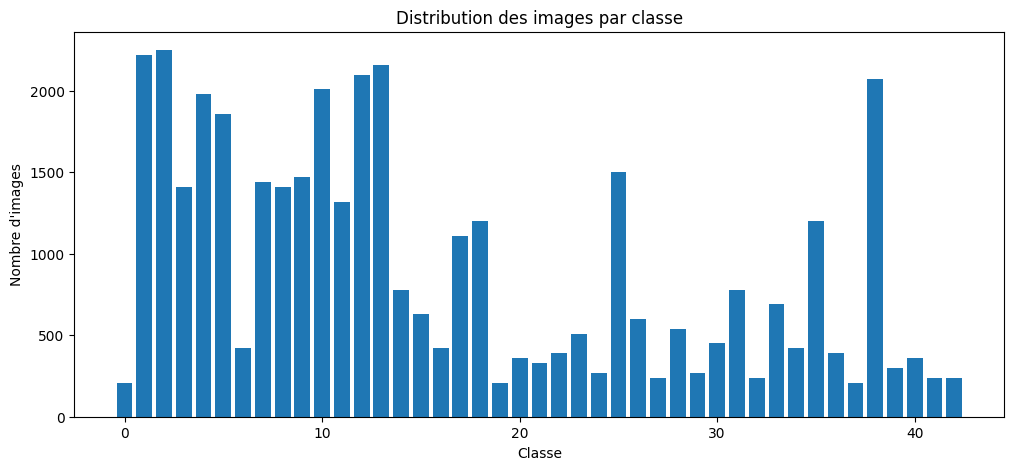

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des images par classe")
plt.show()

## 8. Séparation du dataset

Pour cette première expérimentation, on n'utilise pas tout le dataset.

Découpage choisi :

- 20 % du dataset total pour l'apprentissage et l'évaluation ;
- 10 % du dataset total pour l'inférence finale ;
- le reste du dataset n'est pas utilisé dans cette première version.

Ensuite, les 20 % dédiés à l'apprentissage/évaluation sont séparés en :

- 80 % pour l'entraînement ;
- 20 % pour la validation.


In [9]:
total_size = len(full_dataset)

train_eval_size = int(0.20 * total_size)
inference_size = int(0.10 * total_size)
unused_size = total_size - train_eval_size - inference_size

train_eval_dataset, inference_dataset, unused_dataset = random_split(
    full_dataset,
    [train_eval_size, inference_size, unused_size],
    generator=torch.Generator().manual_seed(42)
)

print("Total dataset :", total_size)
print("Sous-ensemble apprentissage + validation :", len(train_eval_dataset))
print("Sous-ensemble inférence :", len(inference_dataset))
print("Sous-ensemble non utilisé :", len(unused_dataset))

Total dataset : 39209
Sous-ensemble apprentissage + validation : 7841
Sous-ensemble inférence : 3920
Sous-ensemble non utilisé : 27448


## 9. Split entraînement / validation

On divise maintenant les 20 % sélectionnés en deux parties :

- 80 % pour l'entraînement ;
- 20 % pour la validation.


In [10]:
train_size = int(0.80 * len(train_eval_dataset))
val_size = len(train_eval_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_eval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Nombre d'images d'entraînement :", len(train_dataset))
print("Nombre d'images de validation :", len(val_dataset))
print("Nombre d'images réservées pour l'inférence :", len(inference_dataset))

Nombre d'images d'entraînement : 6272
Nombre d'images de validation : 1569
Nombre d'images réservées pour l'inférence : 3920


## 10. Création des DataLoader

Le `DataLoader` fournit les images au modèle sous forme de batchs.

- `train_loader` : données utilisées pour apprendre ;
- `val_loader` : données utilisées pour évaluer le modèle pendant l'entraînement ;
- `inference_loader` : données jamais vues par le modèle, utilisées après l'entraînement.


In [11]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

inference_loader = DataLoader(
    inference_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Nombre de batchs train :", len(train_loader))
print("Nombre de batchs validation :", len(val_loader))
print("Nombre de batchs inférence :", len(inference_loader))

Nombre de batchs train : 98
Nombre de batchs validation : 25
Nombre de batchs inférence : 62


## 11. Vérification d'un batch

On récupère un batch d'entraînement pour vérifier les dimensions.


In [12]:
images, labels = next(iter(train_loader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Exemple de labels :", labels[:10])

Shape images : torch.Size([64, 3, 64, 64])
Shape labels : torch.Size([64])
Exemple de labels : tensor([38,  7,  8, 38,  7,  1,  8, 18, 29,  4])


## 12. Affichage de quelques images

Comme les images ont été normalisées, on les dénormalise uniquement pour l'affichage.
Le modèle, lui, utilisera les images normalisées.


In [13]:
def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)
    return img * std + mean

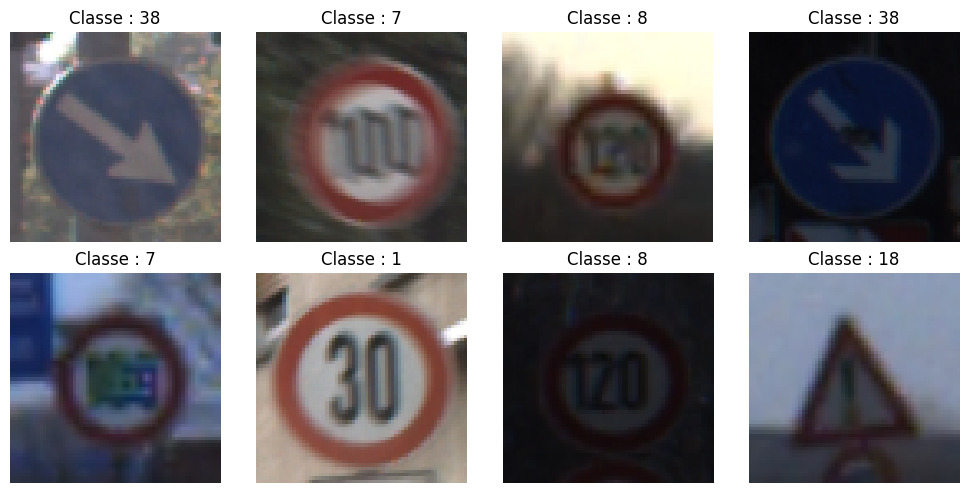

In [14]:
plt.figure(figsize=(10, 5))

for i in range(8):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Classe : {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Conclusion de la préparation des données

Dans cette étape, nous avons :

- téléchargé et extrait le dataset GTSRB ;
- chargé les images avec `ImageFolder` ;
- appliqué un prétraitement simple ;
- analysé la taille du dataset et la distribution des classes ;
- utilisé seulement 20 % du dataset pour l'apprentissage et la validation ;
- réservé 10 % supplémentaires pour l'inférence finale ;
- créé les `DataLoader`.



# 14. Modèle CNN 

On choisit un réseau de neurones convolutif car il est adapté aux images.  
Il permet d'extraire automatiquement des caractéristiques visuelles telles que les contours, les formes et les motifs des panneaux.


In [15]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


## Architecture et hyperparamètres du modèle

Le modèle utilisé est un réseau de neurones convolutif composé de :

- 3 couches de convolution :
  - Conv2d(3 → 32, kernel_size=3, padding=1)
  - Conv2d(32 → 64, kernel_size=3, padding=1)
  - Conv2d(64 → 128, kernel_size=3, padding=1)

- 3 couches de pooling (MaxPool2d, facteur 2)

- 2 couches fully-connected :
  - Linear(128 × 8 × 8 → 256)
  - Linear(256 → 43)

- Une fonction d’activation ReLU après chaque couche de convolution

- Un dropout de 0.5 avant la couche de sortie

---

### Paramètres d’entrée

- Taille des images : 64 × 64 × 3
- Nombre de classes : 43

---

### Hyperparamètres d’entraînement

- Batch size : 64
- Nombre d’epochs : 10
- Optimiseur : Adam
- Learning rate : 0.001
- Fonction de perte : CrossEntropyLoss

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 -> 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [17]:
num_classes = len(full_dataset.classes)

model = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=43, bias=True)
)


## 15. Fonctions d'entraînement et d'évaluation

In [18]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## 16. Entraînement du modèle

In [19]:
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

Epoch [1/10]
Train Loss: 2.7755 | Train Acc: 0.2441
Val Loss:   1.7924 | Val Acc:   0.4449
--------------------------------------------------
Epoch [2/10]
Train Loss: 1.5650 | Train Acc: 0.5062
Val Loss:   1.0088 | Val Acc:   0.6890
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.9027 | Train Acc: 0.7066
Val Loss:   0.4904 | Val Acc:   0.8591
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.4900 | Train Acc: 0.8439
Val Loss:   0.2720 | Val Acc:   0.9261
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.3033 | Train Acc: 0.9058
Val Loss:   0.1891 | Val Acc:   0.9420
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.2127 | Train Acc: 0.9322
Val Loss:   0.1749 | Val Acc:   0.9503
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1549 | Train Acc: 0.9530
Val Loss:   0.1217 | Val Acc:   0.9643
--------------------------------------------------
Epoch 

## 17. Visualisation des performances

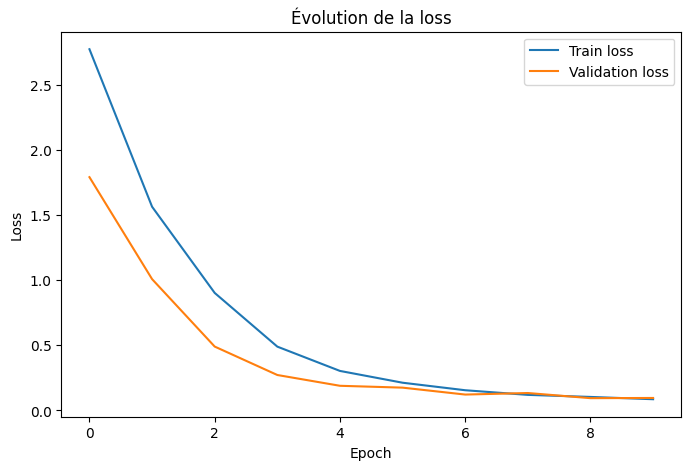

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.legend()
plt.show()

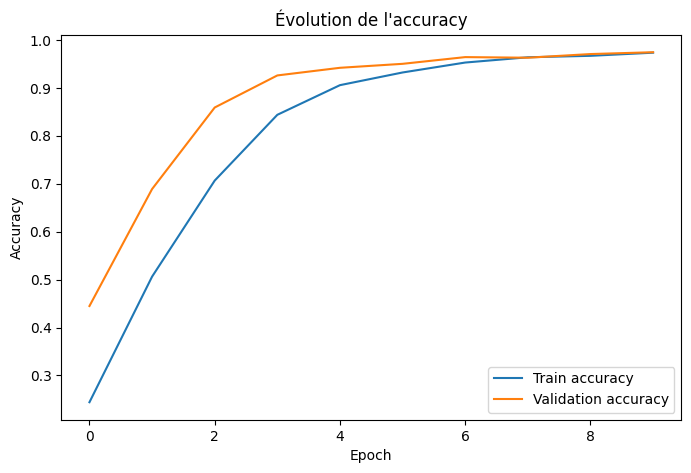

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()
plt.show()

## 18. Sauvegarde du modèle

In [22]:
torch.save(model.state_dict(), "cnn_gtsrb.pth")
print("Modèle sauvegardé : cnn_gtsrb.pth")

Modèle sauvegardé : cnn_gtsrb.pth


# 19. Inférence

On utilise ici le sous-ensemble `inference_dataset`, qui représente 10 % du dataset total.



In [23]:
model.eval()

inference_images, inference_labels = next(iter(inference_loader))
inference_images = inference_images.to(device)
inference_labels = inference_labels.to(device)

with torch.no_grad():
    outputs = model(inference_images)
    _, predictions = torch.max(outputs, 1)

print("Vrais labels :", inference_labels[:10].cpu())
print("Prédictions :", predictions[:10].cpu())

Vrais labels : tensor([ 7, 18,  5, 38, 17, 10, 25, 14,  4, 13])
Prédictions : tensor([ 7, 18,  5, 38, 17, 10, 25, 14,  4, 13])


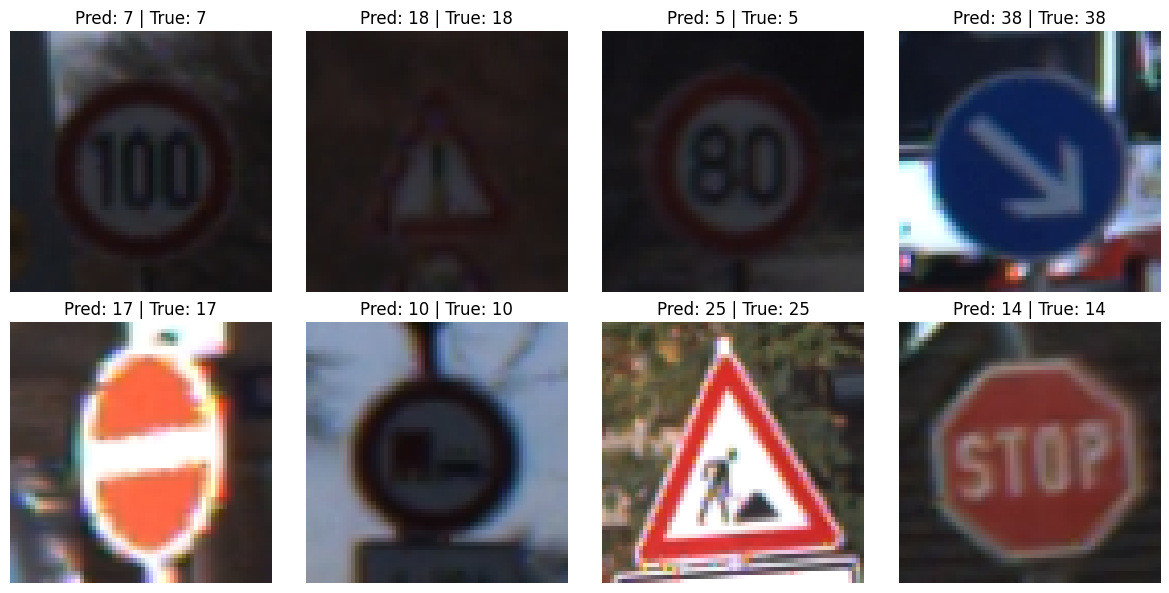

In [24]:
plt.figure(figsize=(12, 6))

for i in range(8):
    img = denormalize(inference_images[i].cpu())
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    true_label = inference_labels[i].item()
    pred_label = predictions[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_label} | True: {true_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 20. Évaluation globale sur le sous-ensemble d'inférence

Cette étape donne une estimation des performances sur des données non vues pendant l'entraînement.


In [25]:
inference_loss, inference_acc = evaluate(
    model,
    inference_loader,
    criterion,
    device
)

print(f"Inference Loss: {inference_loss:.4f}")
print(f"Inference Accuracy: {inference_acc:.4f}")

Inference Loss: 0.0829
Inference Accuracy: 0.9781
